<a href="https://www.kaggle.com/code/adegbaju/parental-genetics-child-trait-prediction?scriptVersionId=325061213" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Parental Genetics & Child Trait Prediction Complete Analysis

 This notebook provides a full exploratory data analysis (EDA), feature engineering, and machine learning pipeline for the synthetic **Parental Genetics & Child Trait Prediction Dataset**.
 
 **Objectives:**
 - Understand distributions and relationships among parental traits and predicted child outcomes.
 - Build a **health risk classifier** (Low, Moderate, High).
 - Build a **child height regressor** and compare with the mid‑parental height formula.
- Predict the **child’s blood group** from parental genetics.
- Demonstrate best practices for handling categorical genetic data.

* Do not forget to upvote*

# Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Try importing XGBoost (optional)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

# Load the dataset

In [2]:
# Adjust the file path if needed (typical Kaggle input path).
df = pd.read_csv('/kaggle/input/datasets/aliyasaly1231/parental-genetics-and-child-trait-prediction-dataset/parental_genetics_child_traits.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7000, 18)


,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


# Data Overview

In [3]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Family_ID                    7000 non-null   object 
 1   Father_Age                   7000 non-null   int64  
 2   Mother_Age                   7000 non-null   int64  
 3   Father_Height_cm             7000 non-null   float64
 4   Mother_Height_cm             7000 non-null   float64
 5   Father_Blood_Group           7000 non-null   object 
 6   Mother_Blood_Group           7000 non-null   object 
 7   Father_Eye_Color             7000 non-null   object 
 8   Mother_Eye_Color             7000 non-null   object 
 9   Father_Hair_Color            7000 non-null   object 
 10  Mother_Hair_Color            7000 non-null   object 
 11  Father_Skin_Tone             7000 non-null   object 
 12  Mother_Skin_Tone             7000 non-null   object 
 13  Family_Disease_His

In [4]:
# Check for missing values and duplicates (should be zero per description)
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Family_ID:", df['Family_ID'].duplicated().sum())

Missing values:
 2461
Duplicate rows: 0
Duplicate Family_ID: 0


In [5]:
# Descriptive statistics for numerical features
df.describe()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,37.650286,34.035857,173.970257,161.084257,167.595814
std,10.323333,9.447972,6.922160,5.971471,8.816473
min,20.000000,18.000000,155.000000,145.000000,140.600000
25%,29.000000,26.000000,169.200000,157.000000,161.100000
50%,38.000000,34.000000,174.000000,161.100000,167.700000
75%,47.000000,42.000000,178.700000,165.200000,174.200000
max,55.000000,50.000000,197.900000,185.000000,198.500000


# Exploratory Data Analysis


## Parental Ages

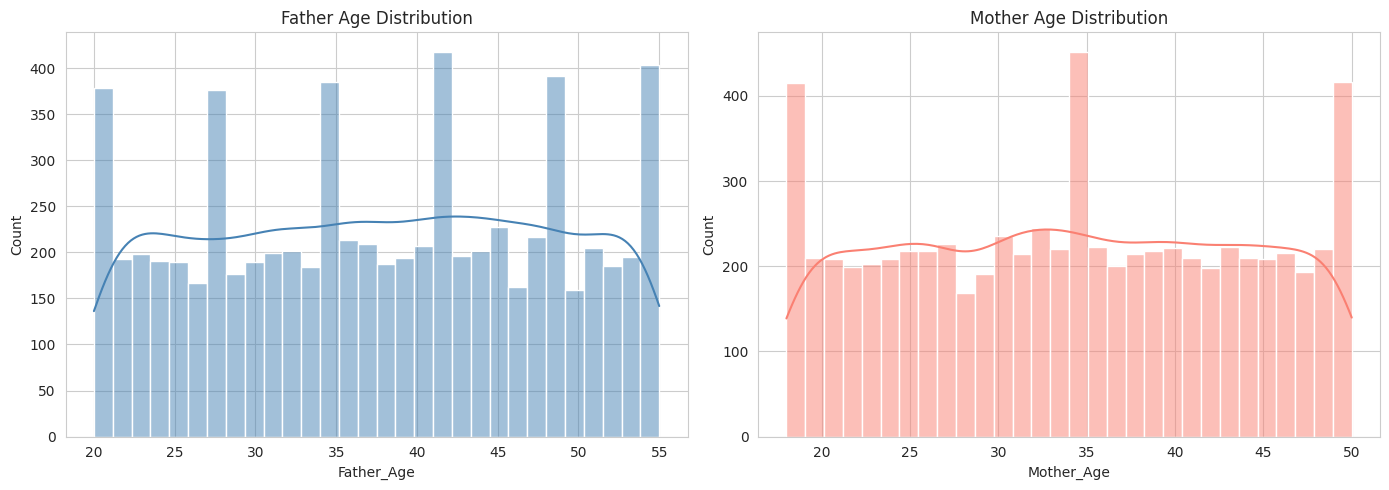

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Father_Age'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Father Age Distribution')
sns.histplot(df['Mother_Age'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Mother Age Distribution')
plt.tight_layout()
plt.show()


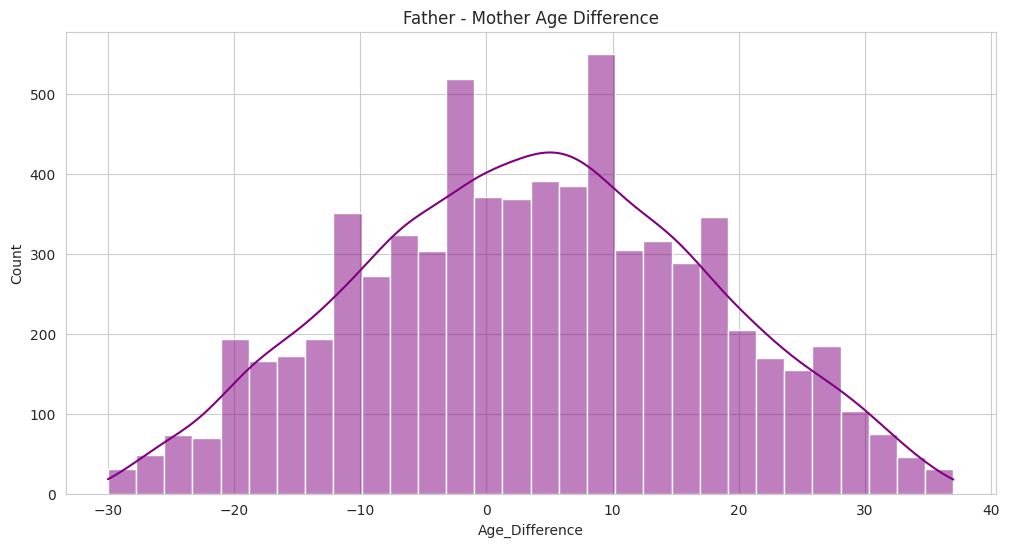

In [7]:
# Age difference
df['Age_Difference'] = df['Father_Age'] - df['Mother_Age']
sns.histplot(df['Age_Difference'], bins=30, kde=True, color='purple')
plt.title('Father - Mother Age Difference')
plt.show()

## Heights

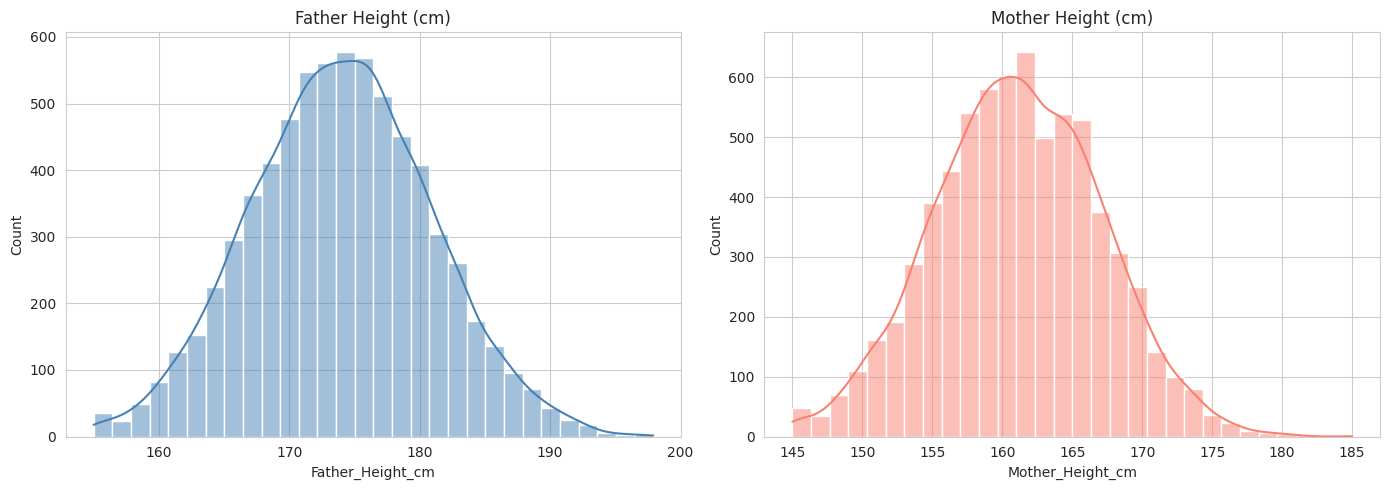

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Father_Height_cm'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Father Height (cm)')
sns.histplot(df['Mother_Height_cm'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Mother Height (cm)')
plt.tight_layout()
plt.show()

In [9]:
# Mid-parental height (commonly used formula)
df['Mid_Parental_Height'] = (df['Father_Height_cm'] + df['Mother_Height_cm']) / 2

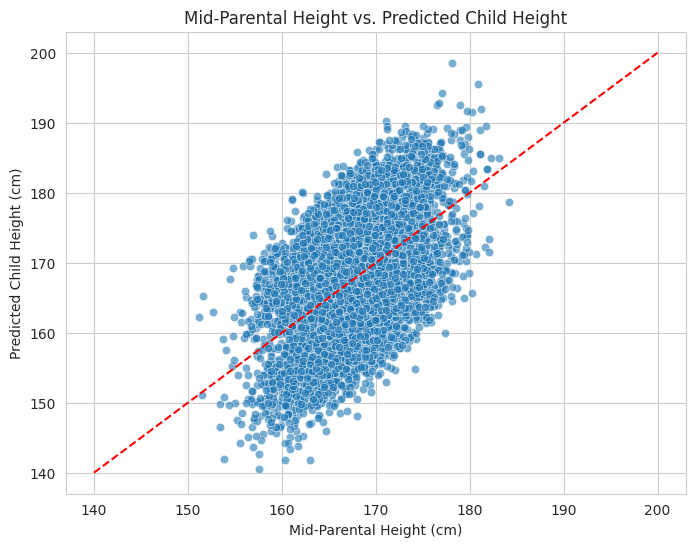

In [10]:
# Compare with dataset's predicted child height
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Mid_Parental_Height'], y=df['Predicted_Child_Height_cm'], alpha=0.6)
plt.plot([140, 200], [140, 200], 'r--')  # diagonal
plt.xlabel('Mid-Parental Height (cm)')
plt.ylabel('Predicted Child Height (cm)')
plt.title('Mid-Parental Height vs. Predicted Child Height')
plt.show()


In [11]:
# Correlation between them
print(f"Correlation: {df['Mid_Parental_Height'].corr(df['Predicted_Child_Height_cm']):.4f}")

Correlation: 0.5088


## Blood Groups  Inheritance Patterns


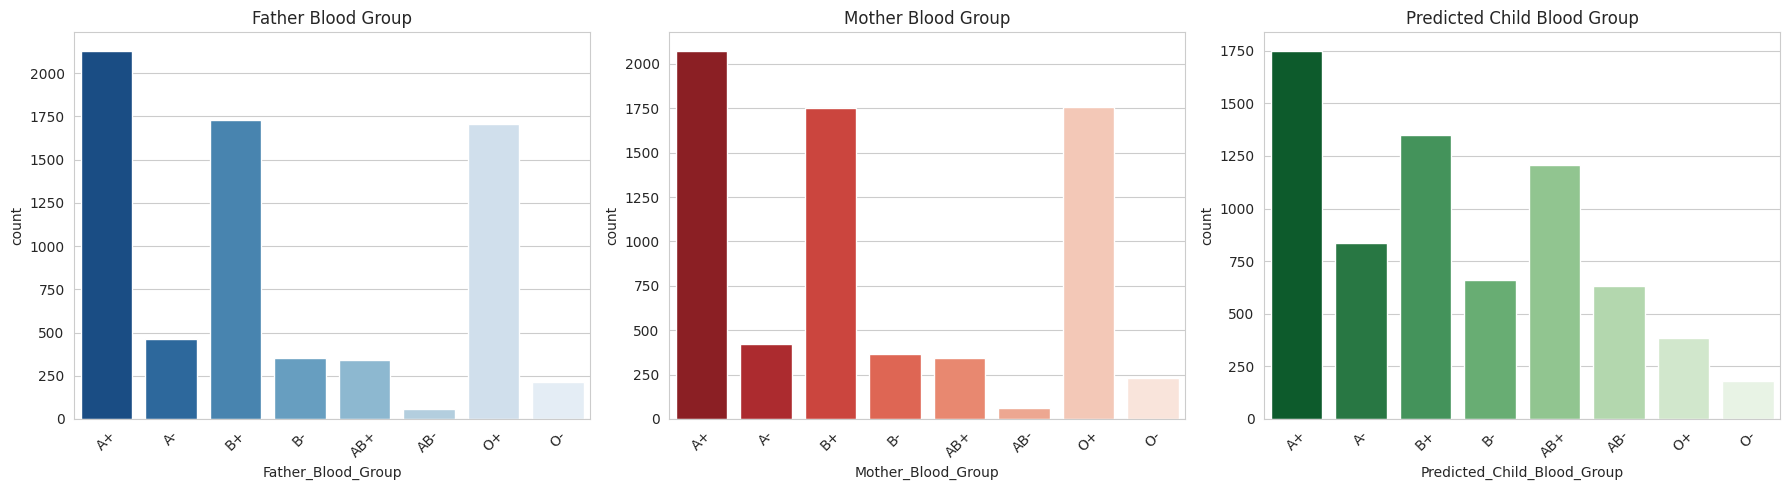

In [12]:
blood_order = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x=df['Father_Blood_Group'], order=blood_order, palette='Blues_r', ax=axes[0])
axes[0].set_title('Father Blood Group')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x=df['Mother_Blood_Group'], order=blood_order, palette='Reds_r', ax=axes[1])
axes[1].set_title('Mother Blood Group')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(x=df['Predicted_Child_Blood_Group'], order=blood_order, palette='Greens_r', ax=axes[2])
axes[2].set_title('Predicted Child Blood Group')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

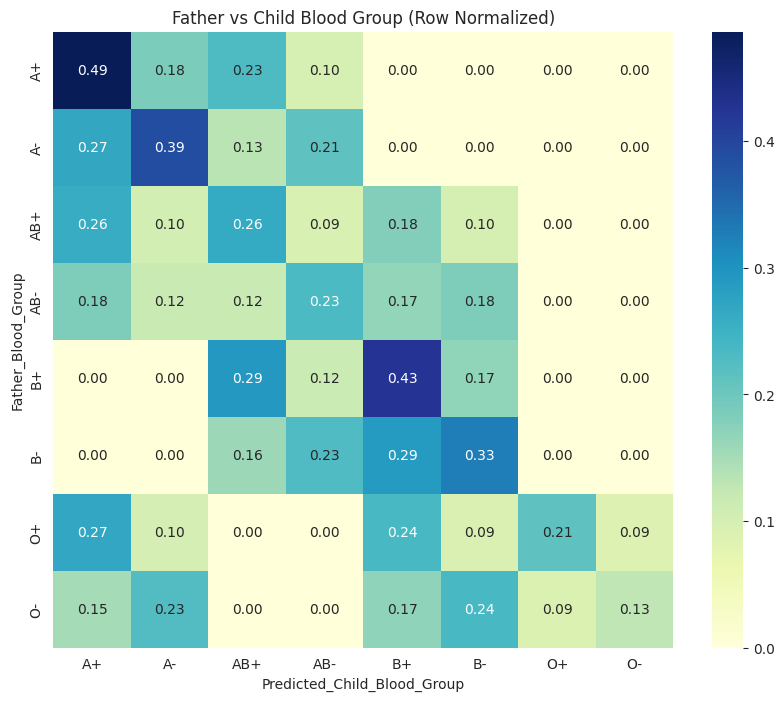

In [13]:
# Cross-tabulation example
ct = pd.crosstab(df['Father_Blood_Group'], df['Predicted_Child_Blood_Group'], normalize='index')
plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Father vs Child Blood Group (Row Normalized)')
plt.show()

## Eye Color Inheritance

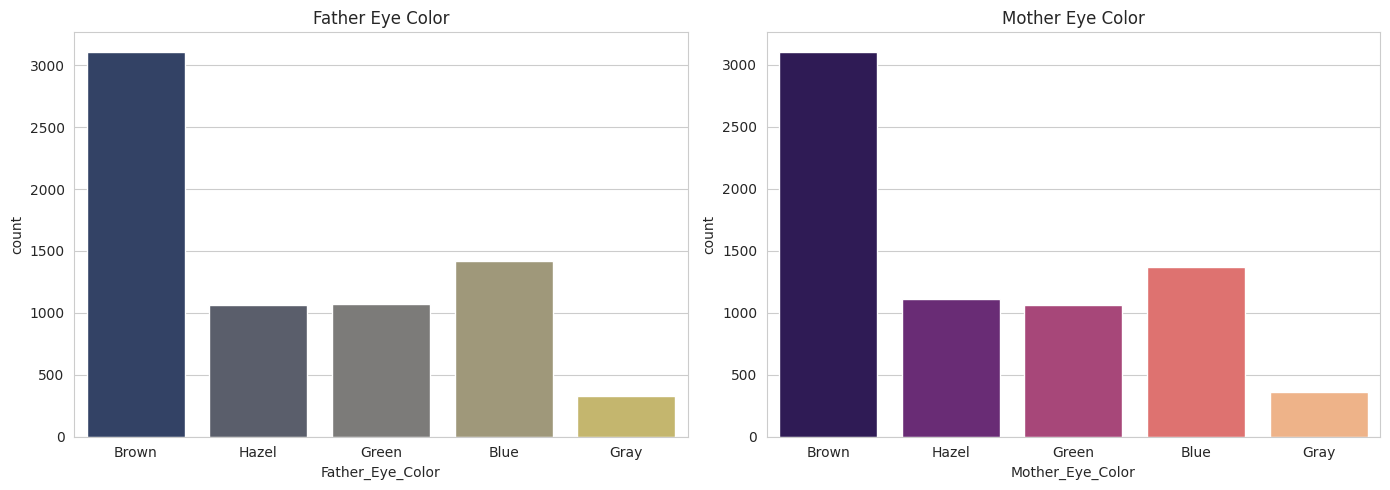

In [14]:
eye_order = ['Brown', 'Hazel', 'Green', 'Blue', 'Gray']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df['Father_Eye_Color'], order=eye_order, palette='cividis', ax=axes[0])
axes[0].set_title('Father Eye Color')
sns.countplot(x=df['Mother_Eye_Color'], order=eye_order, palette='magma', ax=axes[1])
axes[1].set_title('Mother Eye Color')
plt.tight_layout()
plt.show()

## Hair Color Inheritance

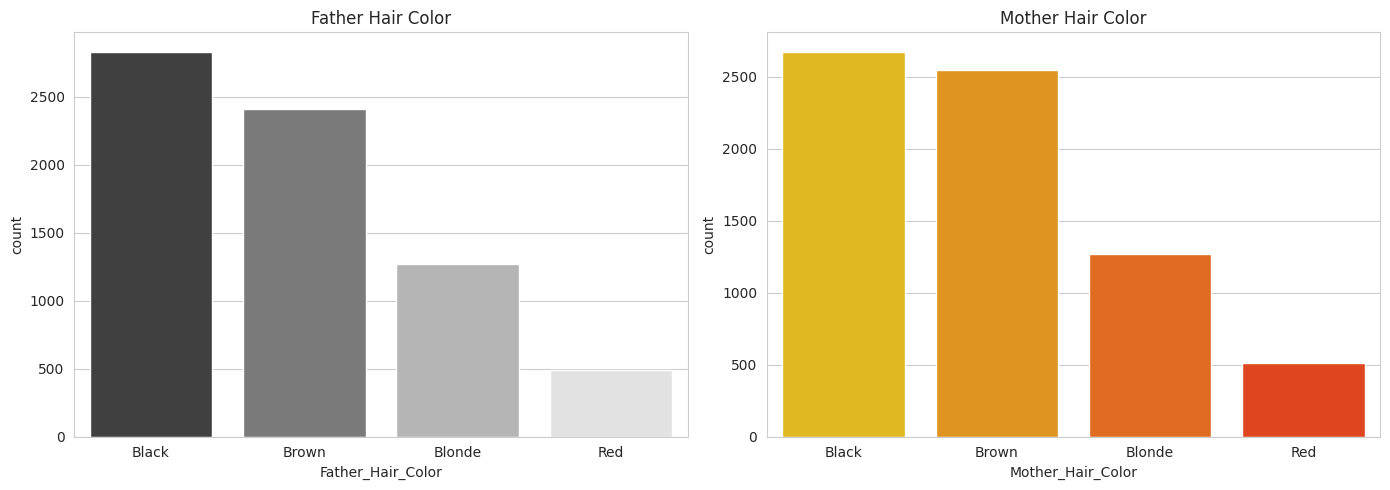

In [15]:
hair_order = ['Black', 'Brown', 'Blonde', 'Red']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df['Father_Hair_Color'], order=hair_order, palette='Greys_r', ax=axes[0])
axes[0].set_title('Father Hair Color')
sns.countplot(x=df['Mother_Hair_Color'], order=hair_order, palette='autumn_r', ax=axes[1])
axes[1].set_title('Mother Hair Color')
plt.tight_layout()
plt.show()

## Skin Tone

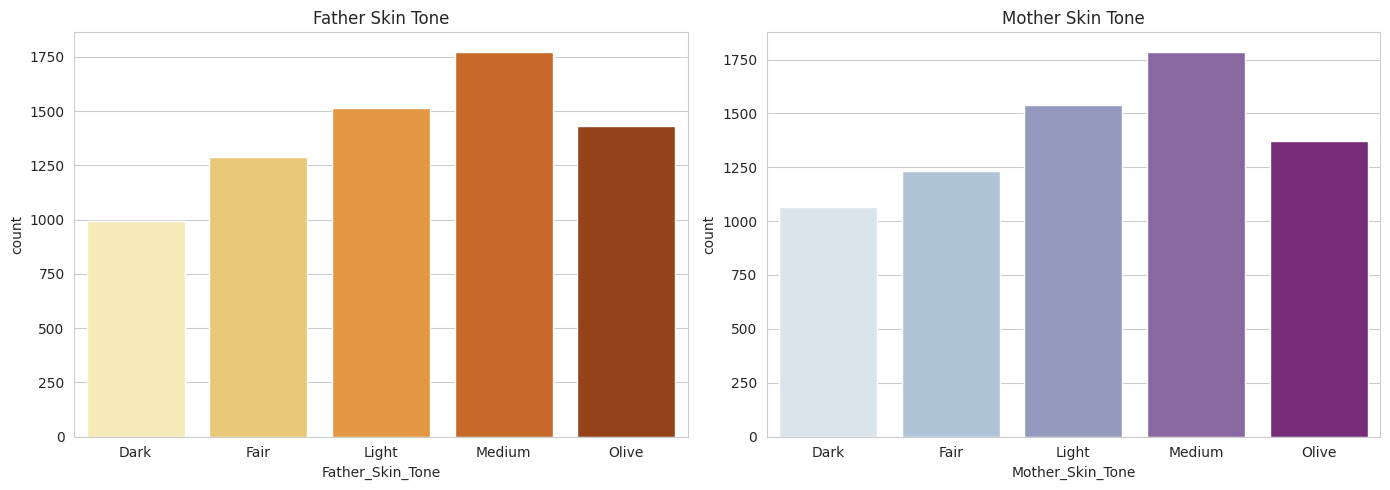

In [16]:
# Assuming skin tone categories (check actual unique values)
skin_order = sorted(df['Father_Skin_Tone'].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df['Father_Skin_Tone'], order=skin_order, palette='YlOrBr', ax=axes[0])
axes[0].set_title('Father Skin Tone')
sns.countplot(x=df['Mother_Skin_Tone'], order=skin_order, palette='BuPu', ax=axes[1])
axes[1].set_title('Mother Skin Tone')
plt.tight_layout()
plt.show()


## Family Disease History

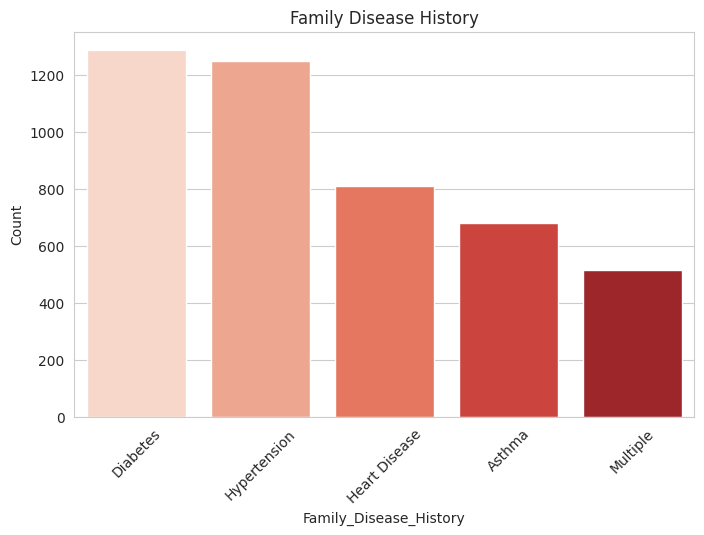

In [17]:
disease_counts = df['Family_Disease_History'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='Reds')
plt.title('Family Disease History')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

## Predicted Child Height Distribution

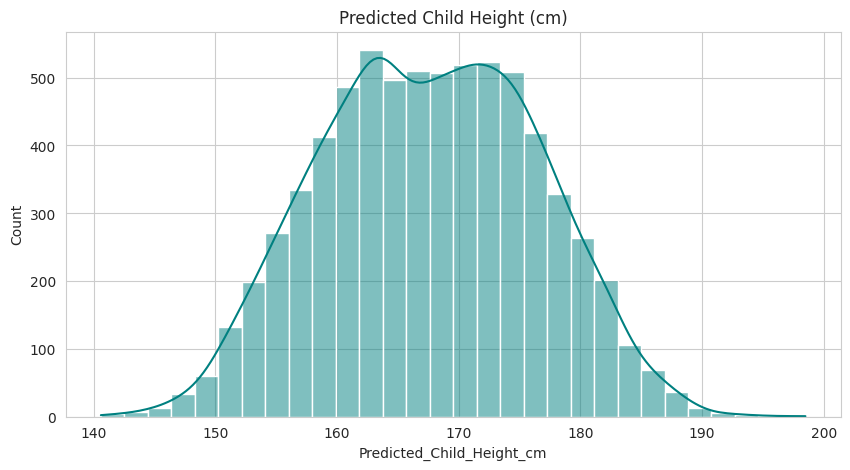

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Predicted_Child_Height_cm'], bins=30, kde=True, color='teal')
plt.title('Predicted Child Height (cm)')
plt.show()

## Predicted Child Blood Group

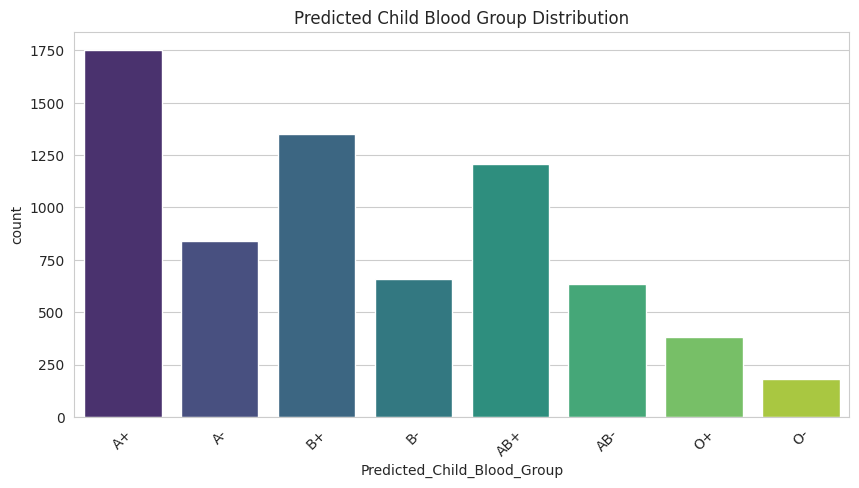

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Predicted_Child_Blood_Group'], order=blood_order, palette='viridis')
plt.title('Predicted Child Blood Group Distribution')
plt.xticks(rotation=45)
plt.show()

## Correlation Heatmap (Numerical Features)

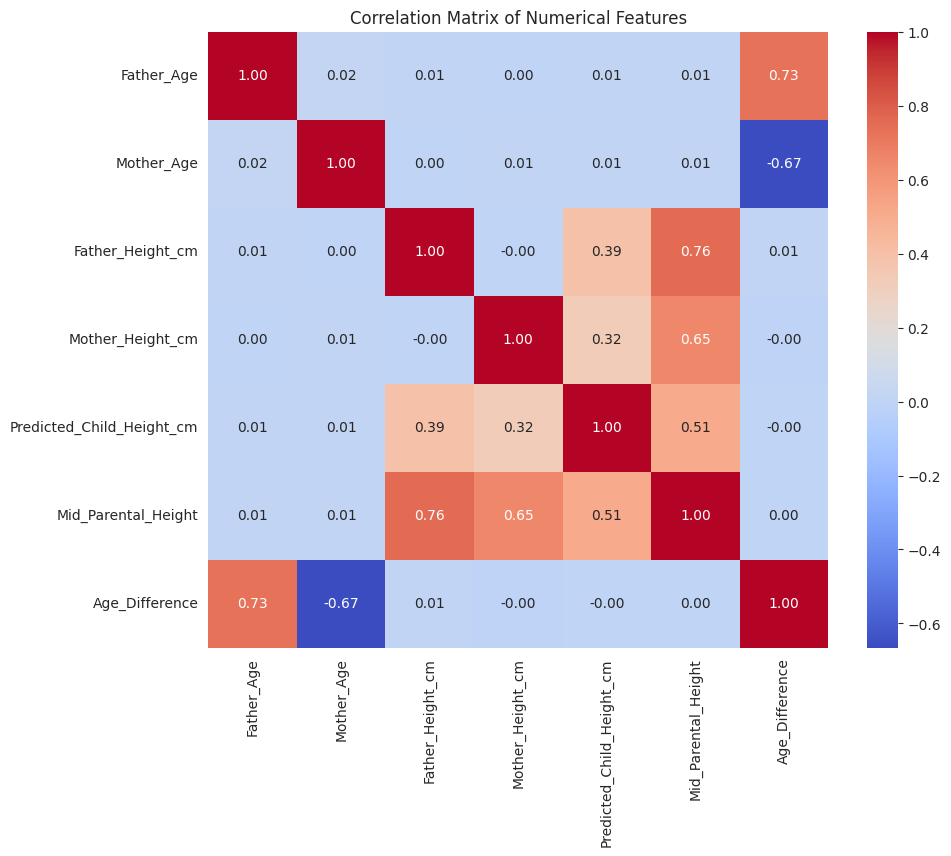

In [20]:
num_cols = ['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm',
            'Predicted_Child_Height_cm', 'Mid_Parental_Height', 'Age_Difference']
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Data Preprocessing for Machine Learning

 We separate features and targets for the three tasks:
 1. **Health Risk Classification** – target: `Predicted_Child_Health_Risk`
 2. **Child Height Regression** – target: `Predicted_Child_Height_cm`
 3. **Blood Group Inheritance** – target: `Predicted_Child_Blood_Group`
 
 We'll encode categorical features consistently. For tree-based models, label encoding is sufficient; for linear models we use one‑hot encoding in a pipeline.


In [21]:
# Drop the identifier column
df_ml = df.drop('Family_ID', axis=1)

# Define feature sets – exclude the three actual target column names
feature_cols = [col for col in df_ml.columns if col not in [
    'Predicted_Health_Risk',          # correct health risk column
    'Predicted_Child_Height_cm',
    'Predicted_Child_Blood_Group'
]]
print("Feature columns:", feature_cols)

# Separate targets
y_risk = df_ml['Predicted_Health_Risk']
y_height = df_ml['Predicted_Child_Height_cm']
y_blood = df_ml['Predicted_Child_Blood_Group']

X = df_ml[feature_cols].copy()

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical   ({len(numerical_cols)}): {numerical_cols}")

Feature columns: ['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm', 'Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History', 'Child_Gender', 'Age_Difference', 'Mid_Parental_Height']
Categorical (10): ['Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History', 'Child_Gender']
Numerical   (6): ['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm', 'Age_Difference', 'Mid_Parental_Height']


 Encoding strategies for each model
 - **Label Encoding** for tree-based models.
 - **One-Hot Encoding** for linear models.


In [22]:
# Label Encoding for all categorical columns (used for tree models)
label_encoders = {}
X_label = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Train/Test split (30% test, stratified for classification)
X_train_lbl, X_test_lbl, y_risk_train, y_risk_test = train_test_split(
    X_label, y_risk, test_size=0.3, random_state=42, stratify=y_risk)
X_train_lbl_h, X_test_lbl_h, y_height_train, y_height_test = train_test_split(
    X_label, y_height, test_size=0.3, random_state=42)
X_train_lbl_b, X_test_lbl_b, y_blood_train, y_blood_test = train_test_split(
    X_label, y_blood, test_size=0.3, random_state=42, stratify=y_blood)


#  Health Risk Classification

## Logistic Regression (with One-Hot Encoding)

In [23]:
# Split the original X (categorical columns remain as strings)
X_train_orig, X_test_orig, y_risk_train_lr, y_risk_test_lr = train_test_split(
    X, y_risk, test_size=0.3, random_state=42, stratify=y_risk
)

# Pipeline for linear model
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train_orig, y_risk_train_lr)
y_risk_pred_lr = lr_pipe.predict(X_test_orig)

print("Logistic Regression Results:")
print(classification_report(y_risk_test_lr, y_risk_pred_lr))



Logistic Regression Results:
              precision    recall  f1-score   support

        High       0.81      0.69      0.74       517
         Low       0.75      0.66      0.70       433
    Moderate       0.76      0.84      0.80      1150

    accuracy                           0.77      2100
   macro avg       0.77      0.73      0.75      2100
weighted avg       0.77      0.77      0.76      2100



## Random Forest Classifier

Random Forest Results:
              precision    recall  f1-score   support

        High       0.83      0.63      0.72       517
         Low       0.77      0.62      0.69       433
    Moderate       0.74      0.87      0.80      1150

    accuracy                           0.76      2100
   macro avg       0.78      0.71      0.73      2100
weighted avg       0.77      0.76      0.76      2100



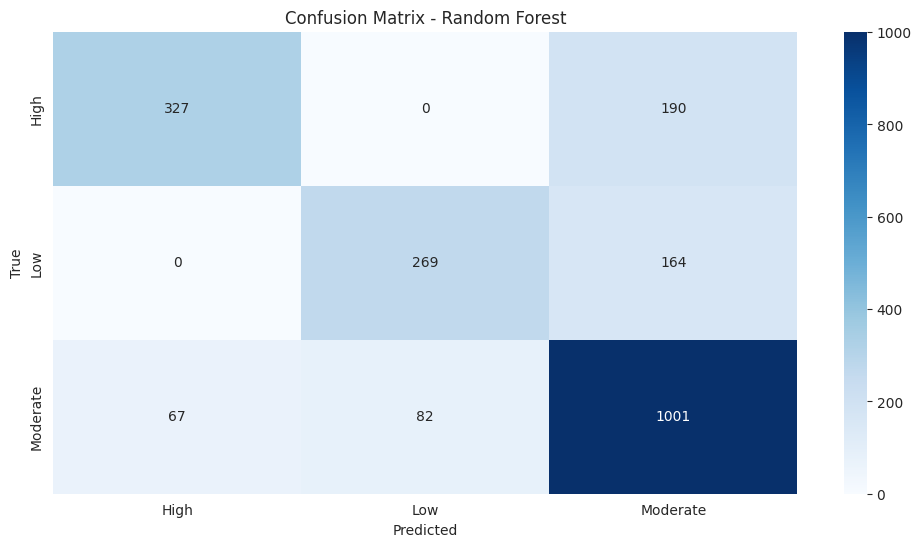

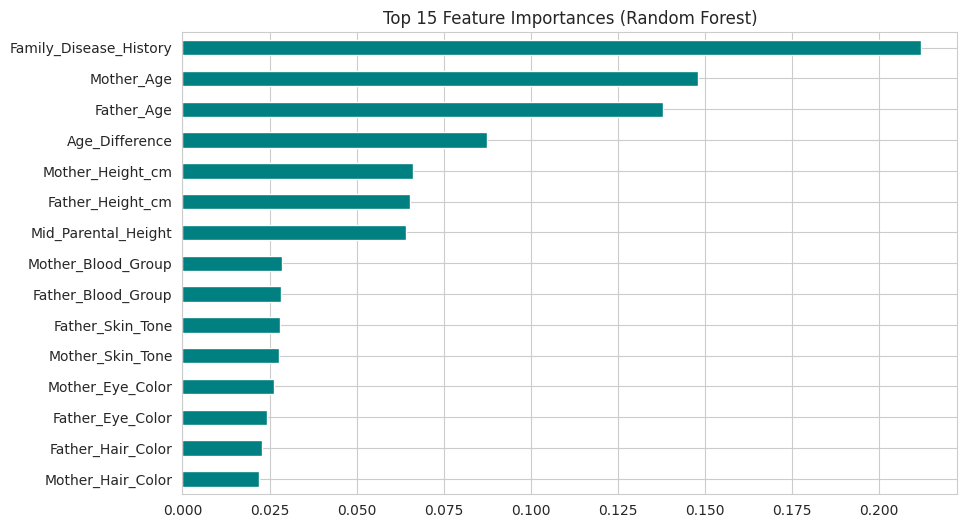

In [24]:
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)
rf_clf.fit(X_train_lbl, y_risk_train)
y_risk_pred_rf = rf_clf.predict(X_test_lbl)

print("Random Forest Results:")
print(classification_report(y_risk_test, y_risk_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_risk_test, y_risk_pred_rf, labels=rf_clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Feature importance
feature_imp = pd.Series(rf_clf.feature_importances_, index=X_label.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_imp.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


## Gradient Boosting & XGBoost 

In [25]:


gb_clf = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb_clf.fit(X_train_lbl, y_risk_train)
y_risk_pred_gb = gb_clf.predict(X_test_lbl)
print("Gradient Boosting Results:")
print(classification_report(y_risk_test, y_risk_pred_gb))

if XGB_AVAILABLE:
    # Encode target labels for XGBoost
    le = LabelEncoder()
    y_risk_train_enc = le.fit_transform(y_risk_train)
    y_risk_test_enc = le.transform(y_risk_test)
    
    xgb_clf = xgb.XGBClassifier(n_estimators=150, random_state=42, eval_metric='mlogloss')
    xgb_clf.fit(X_train_lbl, y_risk_train_enc)
    y_risk_pred_xgb_enc = xgb_clf.predict(X_test_lbl)
    y_risk_pred_xgb = le.inverse_transform(y_risk_pred_xgb_enc)
    print("XGBoost Results:")
    print(classification_report(y_risk_test, y_risk_pred_xgb))

Gradient Boosting Results:
              precision    recall  f1-score   support

        High       0.80      0.73      0.76       517
         Low       0.80      0.68      0.74       433
    Moderate       0.78      0.85      0.81      1150

    accuracy                           0.79      2100
   macro avg       0.79      0.75      0.77      2100
weighted avg       0.79      0.79      0.79      2100

XGBoost Results:
              precision    recall  f1-score   support

        High       0.76      0.68      0.72       517
         Low       0.72      0.65      0.68       433
    Moderate       0.75      0.81      0.78      1150

    accuracy                           0.74      2100
   macro avg       0.74      0.71      0.73      2100
weighted avg       0.74      0.74      0.74      2100



## Model Comparison


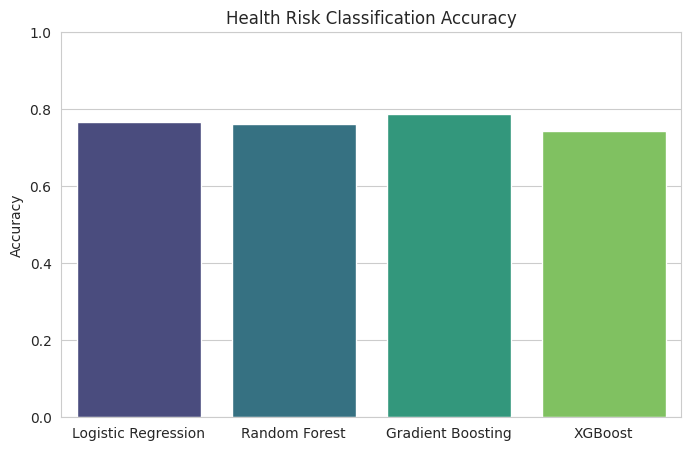

In [26]:
models = {'Logistic Regression': accuracy_score(y_risk_test, y_risk_pred_lr),
          'Random Forest': accuracy_score(y_risk_test, y_risk_pred_rf),
          'Gradient Boosting': accuracy_score(y_risk_test, y_risk_pred_gb)}
if XGB_AVAILABLE:
    models['XGBoost'] = accuracy_score(y_risk_test, y_risk_pred_xgb)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(models.keys()), y=list(models.values()), palette='viridis')
plt.title('Health Risk Classification Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Child Height Prediction (Regression)

## Linear Regression Baseline (mid‑parental height formula)

In [27]:
# Using only mid-parental height as feature
X_simple = df[['Mid_Parental_Height']].values
y_height_all = df['Predicted_Child_Height_cm'].values

# Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_height_all, test_size=0.3, random_state=42)
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train_s)
y_pred_simple = lr_simple.predict(X_test_s)

mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
r2_simple = r2_score(y_test_s, y_pred_simple)
print(f"Linear Regression on Mid-Parental Height only -> MAE: {mae_simple:.3f}, RMSE: {rmse_simple:.3f}, R2: {r2_simple:.3f}")

Linear Regression on Mid-Parental Height only -> MAE: 6.439, RMSE: 7.396, R2: 0.261


## Full Linear Regression (with all features, one‑hot encoded)

In [28]:
# Preprocessor for regression (same as before but without StandardScaler if desired)
preprocessor_reg = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_cols),
                  ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)])

lr_pipe_reg = Pipeline([('preprocessor', preprocessor_reg),
                        ('regressor', LinearRegression())])
lr_pipe_reg.fit(X_train_orig, y_height_train)  # using the same split as for risk (but with height target)
# Use the height split
X_train_orig_h, X_test_orig_h, y_h_train, y_h_test = train_test_split(
    X, y_height, test_size=0.3, random_state=42)
lr_pipe_reg.fit(X_train_orig_h, y_h_train)
y_height_pred_lr = lr_pipe_reg.predict(X_test_orig_h)

mae_lr = mean_absolute_error(y_h_test, y_height_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_h_test, y_height_pred_lr))
r2_lr = r2_score(y_h_test, y_height_pred_lr)
print(f"Full Linear Regression -> MAE: {mae_lr:.3f}, RMSE: {rmse_lr:.3f}, R2: {r2_lr:.3f}")


Full Linear Regression -> MAE: 3.177, RMSE: 3.998, R2: 0.784


## Random Forest Regressor


Random Forest Regressor -> MAE: 3.241, RMSE: 4.093, R2: 0.774


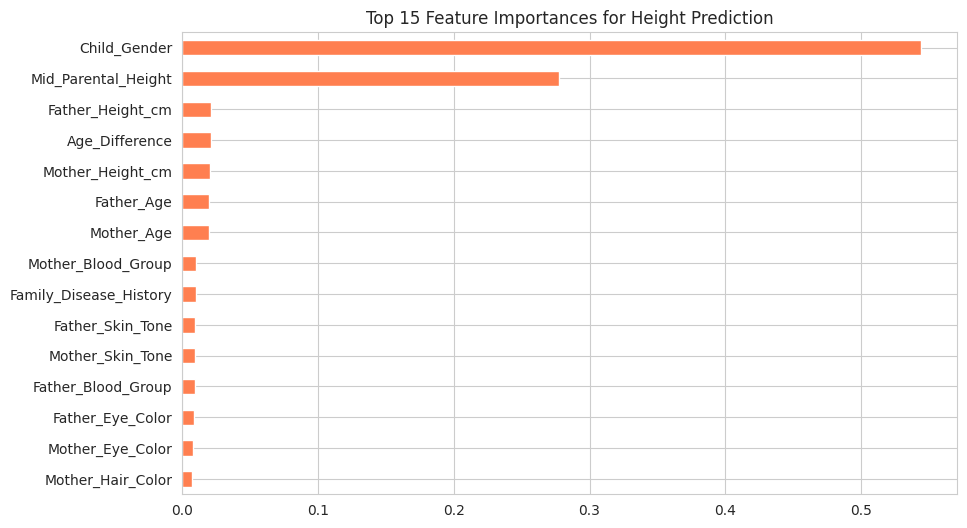

In [29]:
rf_reg = RandomForestRegressor(n_estimators=150, random_state=42)
rf_reg.fit(X_train_lbl_h, y_height_train)
y_height_pred_rf = rf_reg.predict(X_test_lbl_h)

mae_rf = mean_absolute_error(y_height_test, y_height_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_height_test, y_height_pred_rf))
r2_rf = r2_score(y_height_test, y_height_pred_rf)
print(f"Random Forest Regressor -> MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}, R2: {r2_rf:.3f}")

# Feature importance
imp_rf_reg = pd.Series(rf_reg.feature_importances_, index=X_label.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
imp_rf_reg.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Feature Importances for Height Prediction')
plt.gca().invert_yaxis()
plt.show()


## Gradient Boosting Regressor

In [30]:
gb_reg = GradientBoostingRegressor(n_estimators=150, random_state=42)
gb_reg.fit(X_train_lbl_h, y_height_train)
y_height_pred_gb = gb_reg.predict(X_test_lbl_h)

mae_gb = mean_absolute_error(y_height_test, y_height_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_height_test, y_height_pred_gb))
r2_gb = r2_score(y_height_test, y_height_pred_gb)
print(f"Gradient Boosting Regressor -> MAE: {mae_gb:.3f}, RMSE: {rmse_gb:.3f}, R2: {r2_gb:.3f}")

Gradient Boosting Regressor -> MAE: 3.191, RMSE: 4.030, R2: 0.781


## Model Comparison (Regression)


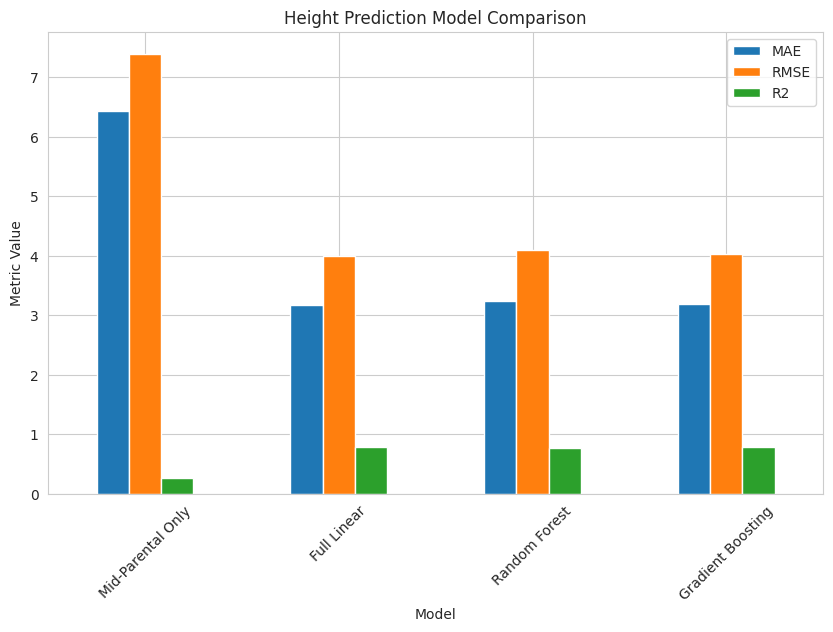

In [31]:
reg_metrics = pd.DataFrame({
    'Model': ['Mid-Parental Only', 'Full Linear', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_simple, mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_simple, rmse_lr, rmse_rf, rmse_gb],
    'R2': [r2_simple, r2_lr, r2_rf, r2_gb]
})
reg_metrics.set_index('Model', inplace=True)
reg_metrics.plot(kind='bar', figsize=(10, 6))
plt.title('Height Prediction Model Comparison')
plt.xticks(rotation=45)
plt.ylabel('Metric Value')
plt.show()

# Blood Group Inheritance Prediction (Multi‑class Classification)

 Because blood group is strictly determined by parental alleles (in reality), this is a rule‑based problem, but we can still test ML.

Blood Group Prediction (Random Forest):
              precision    recall  f1-score   support

          A+       0.67      0.82      0.74       525
          A-       0.50      0.18      0.27       251
         AB+       0.61      0.86      0.72       362
         AB-       0.48      0.15      0.23       190
          B+       0.62      0.91      0.74       405
          B-       0.53      0.08      0.14       198
          O+       0.70      0.90      0.79       115
          O-       0.45      0.17      0.24        54

    accuracy                           0.63      2100
   macro avg       0.57      0.51      0.48      2100
weighted avg       0.60      0.63      0.57      2100



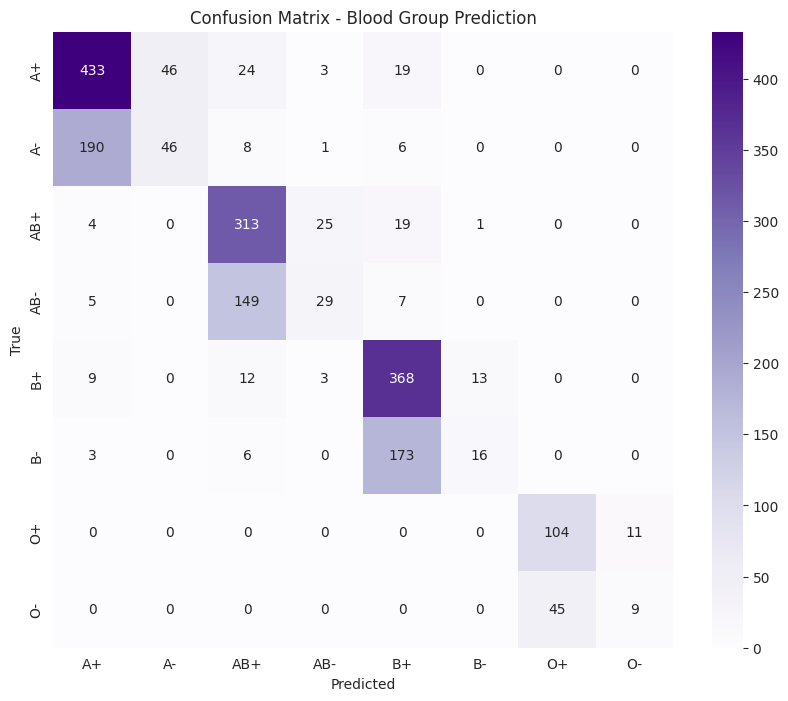

In [32]:
# Using Random Forest
rf_blood = RandomForestClassifier(n_estimators=150, random_state=42)
rf_blood.fit(X_train_lbl_b, y_blood_train)
y_blood_pred_rf = rf_blood.predict(X_test_lbl_b)

print("Blood Group Prediction (Random Forest):")
print(classification_report(y_blood_test, y_blood_pred_rf))

# Confusion matrix
cm_blood = confusion_matrix(y_blood_test, y_blood_pred_rf, labels=rf_blood.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_blood, annot=True, fmt='d', cmap='Purples',
            xticklabels=rf_blood.classes_, yticklabels=rf_blood.classes_)
plt.title('Confusion Matrix - Blood Group Prediction')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Using only Parental Blood Groups as features


In [33]:
X_blood_only = df[['Father_Blood_Group', 'Mother_Blood_Group']].copy()
# Label encode
for col in X_blood_only.columns:
    X_blood_only[col] = LabelEncoder().fit_transform(X_blood_only[col])
y_blood = df['Predicted_Child_Blood_Group'].copy()
# Encode target
le_blood = LabelEncoder()
y_blood_enc = le_blood.fit_transform(y_blood)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_blood_only, y_blood_enc, test_size=0.3, random_state=42, stratify=y_blood_enc)
rf_blood2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_blood2.fit(Xb_train, yb_train)
yb_pred = rf_blood2.predict(Xb_test)
print("Accuracy with only parental blood groups:", accuracy_score(yb_test, yb_pred))
print(classification_report(yb_test, yb_pred, target_names=le_blood.classes_))


Accuracy with only parental blood groups: 0.6614285714285715
              precision    recall  f1-score   support

          A+       0.68      0.86      0.76       525
          A-       0.58      0.29      0.39       251
         AB+       0.65      0.81      0.72       362
         AB-       0.54      0.29      0.38       190
          B+       0.68      0.86      0.76       405
          B-       0.59      0.23      0.33       198
          O+       0.75      0.87      0.80       115
          O-       0.57      0.37      0.45        54

    accuracy                           0.66      2100
   macro avg       0.63      0.57      0.57      2100
weighted avg       0.64      0.66      0.63      2100

